This Notebook is aimed to train an ANN to classify handwriting digits.

## Data and Importing

In [762]:
import sys
import sklearn
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(33)
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
np.random.seed(33)
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

In [763]:
import sklearn.datasets
X_full,y_full = sklearn.datasets.load_digits(return_X_y=True)

In [764]:
X_full.shape

(1797, 64)

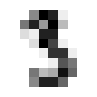

In [765]:
plt.figure(figsize=(1,1))
plt.imshow(X_full[3].reshape(8,8),cmap=plt.cm.gray_r) # 64-digit
plt.axis('off')
plt.show() # show the innerly built fig

In [766]:
X_tr=X_full[:1500]
X_ts=X_full[1500:]
y_tr=y_full[:1500]
y_ts=y_full[1500:]

In [767]:
X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_ts = torch.tensor(X_ts, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_ts = torch.tensor(y_ts, dtype=torch.long)

In [768]:
# 创建数据加载器
tr_dataset = TensorDataset(X_tr, y_tr)
ts_dataset = TensorDataset(X_ts, y_ts)

In [769]:
tr_loader = DataLoader(tr_dataset, batch_size=len(tr_dataset), shuffle=True)
ts_loader = DataLoader(ts_dataset, batch_size=len(ts_dataset), shuffle=False)

## ANN model

In [770]:
class AnnGigitsModel(nn.Module):

    def __init__(self) -> None:
        super(AnnGigitsModel,self).__init__()
        self.layer1=nn.Linear(64,200)
        self.layer2=nn.Linear(200,50)
        self.layer3=nn.Linear(50,10)
    def forward(self,x):
        x=F.relu(self.layer1(x))
        x=F.relu(self.layer2(x))
        x=self.layer3(x) # 最后一层不加relu函数
        return x

In [771]:
ann_digits_model=AnnGigitsModel()
ann_digits_model.parameters

<bound method Module.parameters of AnnGigitsModel(
  (layer1): Linear(in_features=64, out_features=200, bias=True)
  (layer2): Linear(in_features=200, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=10, bias=True)
)>

In [772]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ann_digits_model.parameters(),lr=0.001)

## Train the Model

In [773]:
# 训练模型
num_epochs = 300
tr_losses = []
for epoch in range(num_epochs):
    ann_digits_model.train()
    running_loss = 0.0
    for X_batch, y_batch in tr_loader:
        outputs = ann_digits_model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # 记录每个 epoch 的平均损失
    epoch_loss = running_loss / len(tr_loader)
    tr_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(tr_loader):.4f}")

Epoch [1/300], Loss: 2.4640
Epoch [2/300], Loss: 2.2346
Epoch [3/300], Loss: 2.0755
Epoch [4/300], Loss: 1.9533
Epoch [5/300], Loss: 1.8413
Epoch [6/300], Loss: 1.7253
Epoch [7/300], Loss: 1.6043
Epoch [8/300], Loss: 1.4847
Epoch [9/300], Loss: 1.3708
Epoch [10/300], Loss: 1.2615
Epoch [11/300], Loss: 1.1545
Epoch [12/300], Loss: 1.0505
Epoch [13/300], Loss: 0.9520
Epoch [14/300], Loss: 0.8612
Epoch [15/300], Loss: 0.7780
Epoch [16/300], Loss: 0.7012
Epoch [17/300], Loss: 0.6312
Epoch [18/300], Loss: 0.5687
Epoch [19/300], Loss: 0.5131
Epoch [20/300], Loss: 0.4641
Epoch [21/300], Loss: 0.4204
Epoch [22/300], Loss: 0.3810
Epoch [23/300], Loss: 0.3457
Epoch [24/300], Loss: 0.3148
Epoch [25/300], Loss: 0.2877
Epoch [26/300], Loss: 0.2639
Epoch [27/300], Loss: 0.2427
Epoch [28/300], Loss: 0.2235
Epoch [29/300], Loss: 0.2066
Epoch [30/300], Loss: 0.1916
Epoch [31/300], Loss: 0.1781
Epoch [32/300], Loss: 0.1659
Epoch [33/300], Loss: 0.1550
Epoch [34/300], Loss: 0.1454
Epoch [35/300], Loss: 0

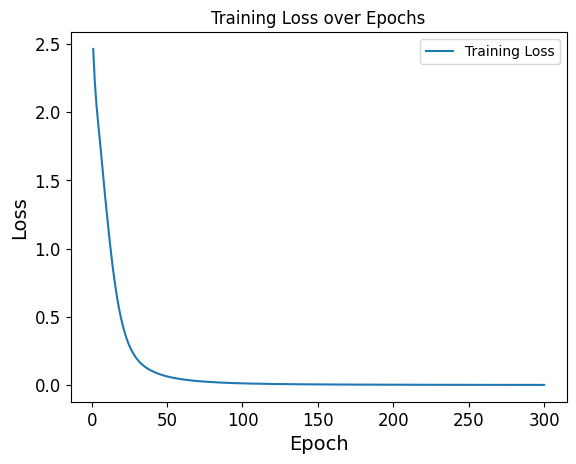

In [774]:
plt.plot(range(1, num_epochs + 1), tr_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

In [775]:
# 测试模型
ann_digits_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in ts_loader:
        outputs = ann_digits_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 91.58%
